# Manual EDA and checks

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Features for synthetic simulations tuned to theoretical values

In [13]:
calib_data = pd.read_excel('results/calibration_data.xlsx', sheet_name="synth by theoretical")

In [14]:
feature_order = ['phi_trans','psi_tan','psi_rad']
hue_order = ['Theoretical (10 fish)','Synthetic dataset','Real dataset']
feature_labels = {
    "phi_trans": r"$\Phi_{\mathrm{trans}}$",
    "psi_tan":   r"$\Psi_{\mathrm{tan}}$",
    "psi_rad":   r"$\Psi_{\mathrm{rad}}^{\pm}$",
}

In [15]:
behavior_order = calib_data["behavior"].drop_duplicates().tolist()
colors = ['#5C847C','#E5943D','#7DC4BE']

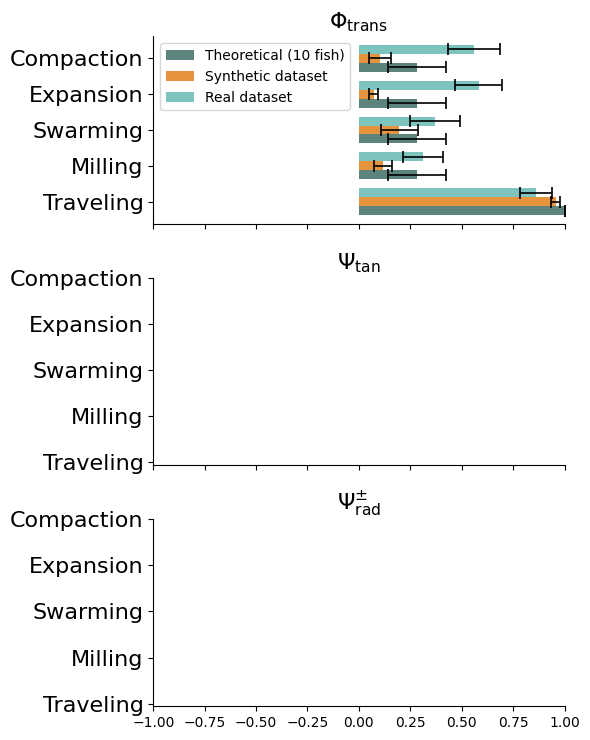

In [16]:
fig, axes = plt.subplots(
    len(feature_order),
    1,
    figsize=(6, 2.5 * len(feature_order)),
    sharex=True,
)

axes = np.atleast_1d(axes)

bar_height = 0.25
offsets = (
    np.arange(len(hue_order))
    - (len(hue_order) - 1) / 2
) * bar_height


def plot_feature(feature: str, axis_id: int):
    ax = axes[axis_id]
    y = np.arange(len(behavior_order))

    for i, dataset in enumerate(hue_order):
        sub = (
            calib_data[
                (calib_data["feature"] == feature)
                & (calib_data["dataset"] == dataset)
            ]
            .set_index("behavior")
            .reindex(behavior_order)
        )

        means = sub["feature mean"].to_numpy(dtype=float)
        stds = sub["feature std"].to_numpy(dtype=float)
        positions = y + offsets[i]
        valid = ~np.isnan(means)

        ax.barh(
            positions[valid],
            means[valid],
            height=bar_height,
            xerr=stds[valid],
            capsize=4,
            color=colors[i],
            label=dataset,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2,
            },
        )

    ax.set_yticks(y)
    ax.set_yticklabels(
        [behavior.capitalize() for behavior in behavior_order],
        fontsize=16,
    )
    ax.set_title(feature_labels[feature], fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(-1.0, 1.0)

    if axis_id == 0:
        ax.legend(frameon=True)


for axis_id, feature in enumerate(feature_order):
    plot_feature(feature=feature, axis_id=axis_id)

sns.despine()
plt.tight_layout()
plt.show()


## Features for synthetic simulations tuned to real dataset

In [17]:
calib_data = pd.read_excel('results/calibration_data_new_features.xlsx', sheet_name="synth by real")

In [18]:
feature_order = ['phi_trans','psi_tan','psi_rad']
hue_order = ['Theoretical','Synthetic dataset','CouzinLab dataset']
feature_labels = {
    "phi_trans": r"$\Phi_{\mathrm{trans}}$",
    "psi_tan":   r"$\Psi_{\mathrm{tan}}$",
    "psi_rad":   r"$\Psi_{\mathrm{rad}}^{\pm}$",
}

In [19]:
behavior_order = calib_data["behavior"].drop_duplicates().tolist()
colors = ['#5C847C','#E5943D','#7DC4BE']

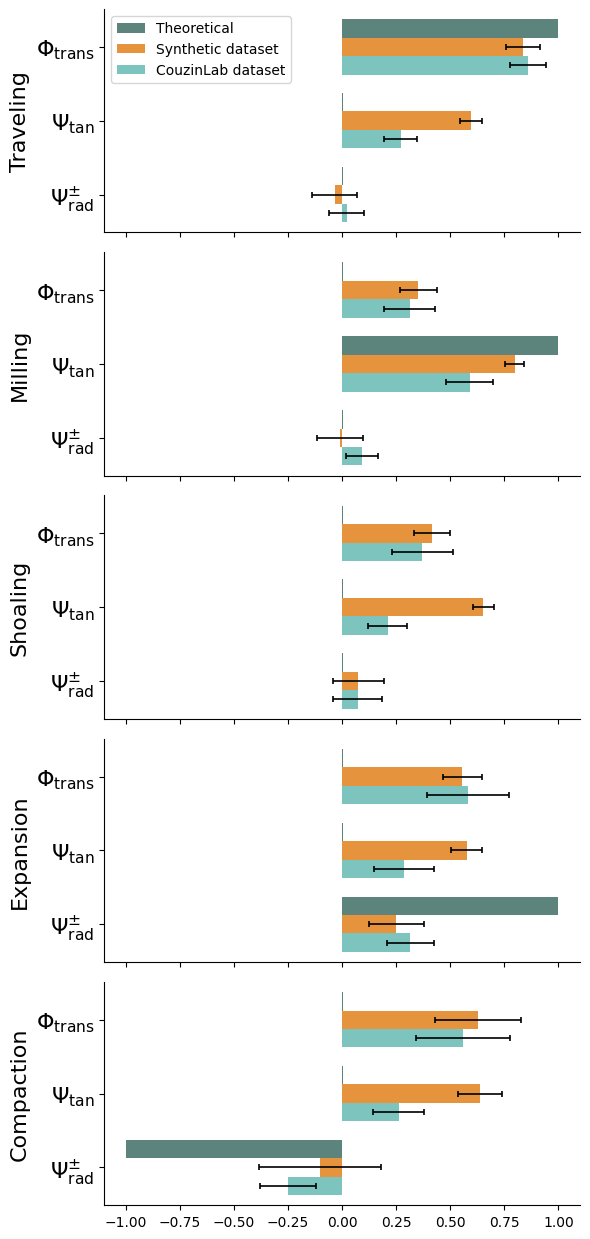

In [20]:
fig, axes = plt.subplots(
    len(behavior_order),
    1,
    figsize=(6, 2.5 * len(behavior_order)),
    sharex=True,
)

# Makes sure axes is always iterable even if there is only one subplot
axes = np.atleast_1d(axes)

def plot_behavior(behavior: str, axis_id: int):

    ax = axes[axis_id]

    # Filter dataframe
    d = calib_data[calib_data["behavior"] == behavior].copy()

    # Y positions of the three features
    y = np.arange(len(feature_order))

    # Height of each individual bar
    bar_height = 0.25

    # Offsets for hue:
    # dataset 1 -> bottom
    # dataset 2 -> center
    # dataset 3 -> top
    offsets = (
        np.arange(len(hue_order))
        - (len(hue_order) - 1) / 2
    ) * bar_height

    # -----------------------------------------------------
    # Draw each dataset separately
    # -----------------------------------------------------

    for i, dataset in enumerate(hue_order):

        sub = (
            d[d["dataset"] == dataset]
            .set_index("feature")
            .reindex(feature_order)
        )

        means = sub["feature mean"].to_numpy(dtype=float)
        stds = sub["feature std"].to_numpy(dtype=float)

        positions = y + offsets[i]

        # Handle missing combinations safely
        valid = ~np.isnan(means)
        if i == 0:
            ax.barh(
                positions[valid],
                means[valid],
                height=bar_height,
                color=colors[i],
                label=dataset,
            )
        else:
            ax.barh(
                positions[valid],
                means[valid],
                height=bar_height,
                xerr=stds[valid],
                capsize=2,
                color=colors[i],
                label=dataset,
                error_kw={
                    "elinewidth": 1.2,
                    "capthick": 1.2
                }
            )
    # -----------------------------------------------------
    # Axis formatting
    # -----------------------------------------------------

    ax.set_yticks(y)
    ax.set_yticklabels(
        [feature_labels[f] for f in feature_order],
        fontsize=16
    )
    ax.invert_yaxis()

    ax.set_ylabel(
        behavior.capitalize(),
        fontsize=16,
    )

    ax.set_xlabel("")

    ax.set_xlim(-1.1, 1.1)

    # Only show legend in first subplot
    if axis_id == 0:
        ax.legend(frameon=True)


# ---------------------------------------------------------
# Plot all behaviors
# ---------------------------------------------------------

for axis_id, behavior in enumerate(behavior_order):
    plot_behavior(
        behavior=behavior,
        axis_id=axis_id
    )


# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

sns.despine()

plt.tight_layout()

plt.savefig('results/behavior_bars.png', dpi=300)

plt.show()
